In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("loan_data.csv")
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [2]:
df.isnull().sum()

credit.policy        0
purpose              0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64

In [3]:
target_counts = df["not.fully.paid"].value_counts()
target_percent = df["not.fully.paid"].value_counts(normalize=True) * 100

print("Counts:\n", target_counts)
print("\nPercentage:\n", target_percent)

Counts:
 not.fully.paid
0    8045
1    1533
Name: count, dtype: int64

Percentage:
 not.fully.paid
0    83.994571
1    16.005429
Name: proportion, dtype: float64


In [4]:
from sklearn.model_selection import train_test_split

X = df.drop("not.fully.paid", axis=1)
y = df["not.fully.paid"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

print("Before balance:", y_train.value_counts())
print("After balance:", y_train_bal.value_counts())

Before balance: not.fully.paid
0    6436
1    1226
Name: count, dtype: int64
After balance: not.fully.paid
0    6436
1    6436
Name: count, dtype: int64


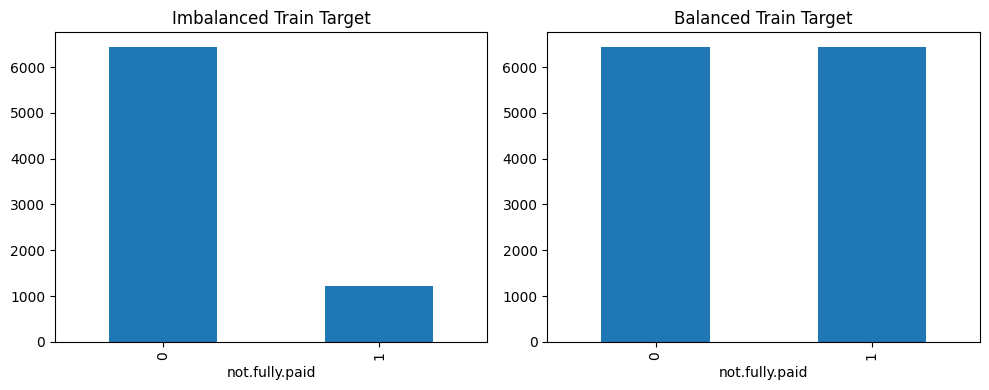

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10,4))

y_train.value_counts().plot(kind="bar", ax=ax[0], title="Imbalanced Train Target")
y_train_bal.value_counts().plot(kind="bar", ax=ax[1], title="Balanced Train Target")

plt.tight_layout()
plt.show()

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

cat_cols = ["purpose"]
num_cols = [col for col in X.columns if col not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

In [8]:
X_train_processed = preprocessor.fit_transform(X_train_bal)
X_test_processed  = preprocessor.transform(X_test)

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

input_dim = X_train_processed.shape[1]

model = Sequential([
    Dense(128, activation="relu", input_shape=(input_dim,)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

model.summary()

C:\Users\viswa\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           2,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,881 (42.50 KB)

 Trainable params: 10,881 (42.50 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed,
    y_train_bal,
    epochs=25,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/25
322/322 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6581 - auc: 0.6594 - loss: 0.6241 - val_accuracy: 0.4004 - val_auc: 0.0000e+00 - val_loss: 0.8444
Epoch 2/25
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6666 - auc: 0.6910 - loss: 0.6067 - val_accuracy: 0.4450 - val_auc: 0.0000e+00 - val_loss: 0.8438
Epoch 3/25
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6757 - auc: 0.6972 - loss: 0.6036 - val_accuracy: 0.3802 - val_auc: 0.0000e+00 - val_loss: 0.8677
Epoch 4/25
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6830 - auc: 0.7075 - loss: 0.5959 - val_accuracy: 0.3332 - val_auc: 0.0000e+00 - val_loss: 0.9147
Epoch 5/25
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6859 - auc: 0.7120 - loss: 0.5929 - val_accuracy: 0.4237 - val_auc: 0.0000e+00 - val_loss: 0.8001
Epoch 6/25
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6864 - auc: 0.7197 - loss: 0.5884 - val_accuracy: 0.4206 - val_auc: 0.0000e+00 - val_loss: 0.8334
Epoch 7/25
322/

In [12]:
from sklearn.metrics import confusion_matrix

y_pred_proba = model.predict(
    X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed
).ravel()

# default threshold = 0.5
y_pred = (y_pred_proba >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
print("Confusion Matrix:\n", cm)
print("Sensitivity (Recall for defaulters):", sensitivity)

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Confusion Matrix:
 [[1400  209]
 [ 213   94]]
Sensitivity (Recall for defaulters): 0.30618892508143325


In [13]:
from sklearn.metrics import roc_auc_score, roc_curve

auc_score = roc_auc_score(y_test, y_pred_proba)
print("AUC ROC Score:", auc_score)

AUC ROC Score: 0.6676896852598273


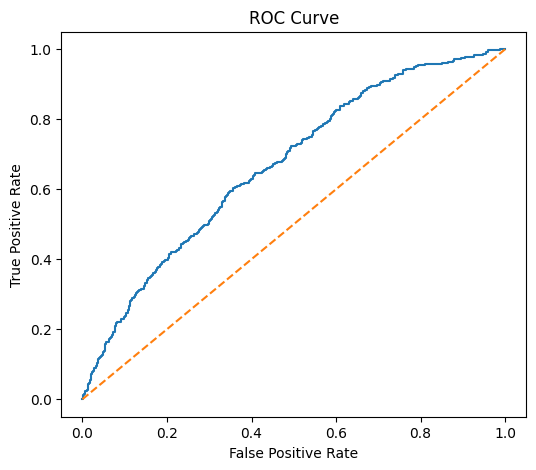

In [14]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [15]:
threshold = 0.35
y_pred_tuned = (y_pred_proba >= threshold).astype(int)

cm2 = confusion_matrix(y_test, y_pred_tuned)
tn, fp, fn, tp = cm2.ravel()
sensitivity2 = tp / (tp + fn)

print("Threshold:", threshold)
print("Confusion Matrix:\n", cm2)
print("Sensitivity:", sensitivity2)

Threshold: 0.35
Confusion Matrix:
 [[1085  524]
 [ 139  168]]
Sensitivity: 0.5472312703583062
